# __Байесовские сети__

## 0. Выбор датасета.

In [37]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("maharshipandya/-spotify-tracks-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\User\.cache\kagglehub\datasets\maharshipandya\-spotify-tracks-dataset\versions\1


In [38]:
import pandas as pd
import os
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

In [39]:
files = os.listdir(path)
files

['dataset.csv']

In [40]:
df = pd.read_csv(os.path.join(path, 'dataset.csv'))
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


- Я слушал музыку, и подумал, что можно взять данные по Я.музыке, но таких данных я не нашёл, зато есть спотифай.

## 1. Категориальные/бинарные признаки. Ожидаемые зависимости между ними.

In [41]:
data = pd.DataFrame()

# наша целевая переменная, популярность песни
data['IsPopular'] = df['popularity'] > 70

# наши родители:
# 1. danceability - танцевальность
data['IsDanceable'] = df['danceability'] > 0.7

# 2. energy - энергичность
data['IsEnergetic'] = df['energy'] > 0.7

# 3. explicit - мат
data['IsExplicit'] = df['explicit'].astype(bool)

data = data.dropna()

data.head()

,IsPopular,IsDanceable,IsEnergetic,IsExplicit
0,True,False,False,False
1,False,False,False,False
2,False,False,False,False
3,True,False,False,False
4,True,False,False,False


Наша логика:

- IsEnergetic -> IsDanceable: обычно энергичные песни более танцевальные. 

- IsDanceable -> IsPopular: танцевальные песни очень заедающие и популярные.

- IsExplicit -> IsPopular: песни с матом часто привлекают внимание, но в этот же момент многие люди такие песни не слушает восем.

## 2. Структура DAG.

__ВИЗУАЛИЗАЦИЯ ГРАФА__

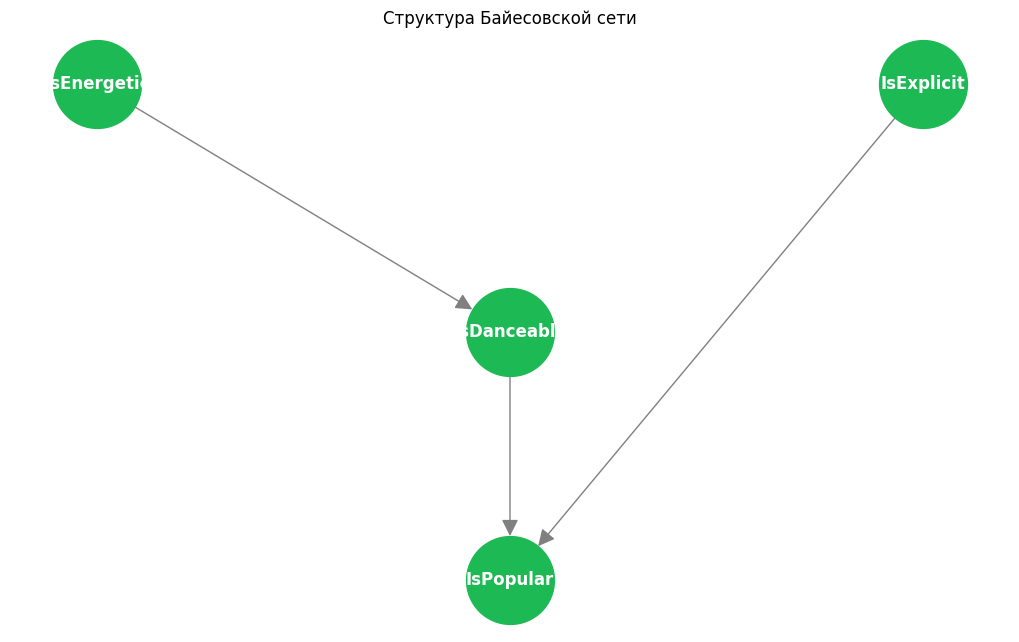

In [42]:
G = nx.DiGraph()

edges = [
    ('IsEnergetic', 'IsDanceable'), 
    ('IsDanceable', 'IsPopular'),  
    ('IsExplicit', 'IsPopular')     
]
G.add_edges_from(edges)

plt.figure(figsize=(10, 6))
pos = {
    'IsEnergetic': (0, 1),   
    'IsDanceable': (1, 0.5),  
    'IsExplicit': (2, 1),     
    'IsPopular': (1, 0)       
}

nx.draw(G, pos, with_labels=True, node_size=4000, 
        node_color="#1DB954",
        font_color="white", font_weight='bold', font_size=12,
        arrowsize=25, edge_color="gray")

plt.title('Структура Байесовской сети')
plt.axis('off')
plt.show()

## 3. Построение CPT по данным Spotify Tracks.

Conditional Probability Table (CPT)

In [43]:
cpt_popular = pd.crosstab(
    index=[data['IsDanceable'], data['IsExplicit']], 
    columns=data['IsPopular'],
    normalize='index' 
)

cpt_popular.columns = ['Не популярен', 'популярен (Target)']
cpt_popular.index.names = ['Танцевальный?', 'Есть мат?']

display(cpt_popular)

Не популярен  популярен (Target)
Танцевальный? Есть мат?                                  
False         False          0.964114            0.035886
              True           0.930932            0.069068
True          False          0.952020            0.047980
              True           0.893496            0.106504

- Наихудшая стратегия для артиста — писать медленные песни без матов (вероятность успеха около 0.035886).
- Наилучшая стратегия — создавать энергичные танцевальные треки с матами (вероятность успеха около 0.106504). 

Модель показывает, что такая комбинация увеличивает шансы на попадание в топ-чарты в 3 раза.

## 4. Считаем условные вероятности. Сравниваем их с нашими ожиданиями.

In [44]:
# P(A | B) = P(A & B) / P(B)

# 1. P(Popular | Explicit)
p_pop_given_explicit = (data['IsPopular'] & data['IsExplicit']).mean() / data['IsExplicit'].mean()

# 2. P(Popular | Danceable)
p_pop_given_dance = (data['IsPopular'] & data['IsDanceable']).mean() / data['IsDanceable'].mean()

# 3. P(Popular | Danceable, Explicit)
condition_combo = (data['IsDanceable'] & data['IsExplicit'])
p_pop_given_combo = (data['IsPopular'] & condition_combo).mean() / condition_combo.mean()

p_pop_given_explicit, p_pop_given_dance, p_pop_given_combo

(0.08453883246127013, 0.05663216618953241, 0.10650446871896722)

## 5. Итоги лабораторной работы по Байевским сетям.

### Пояснения по условным вероятностям

1.  **$P(\text{Popular} | \text{Explicit}) \approx 0.0845$**
    При условии наличия нецензурной лексики, шанс трека стать хитом составляет **8.5%**.

    Оказалось, что просто сделать трек танцевальным недостаточно. Вероятность стать супер-хитом (популярность > 70) у таких песен всего 5.7%. Это даже ниже, чем у треков с матом. Видимо, рынок перенасыщен простой танцевальной музыкой.

2.  **$P(\text{Popular} | \text{Danceable}) \approx 0.0566$**
    При условии, что трек танцевальный, вероятность популярности равна **5.6%**.

    Наличие нецензурной лексики (Explicit) повышает шансы на успех до 8.5%. Это в 1.5 раза выше, чем у просто танцевальных треков. Это подтверждает гипотезу, что более дерзкий/провокационный контент привлекает больше внимания.

3.  **$P(\text{Popular} | \text{Dance}, \text{Explicit}) \approx 0.1065$**
    Комбинация обоих факторов дает вероятность **10.7%**.

### Что нового позволяет заметить сеть
Данные показывают, что факторы работают вместе. По отдельности "танцевальность" работает слабо, но в сочетании с "бранью" она дает максимальный результат. Мы видим классический пример синергетического эффекта в данных.

Проценты такие маленькие, потому что я поставил достаточно жесткие условия, порог популярности должен быть больше 70.